<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
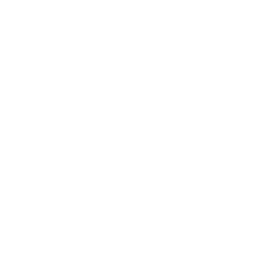
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diseño de Parcelas Divididas para la Optimización de Procesos</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufactura / Ingeniería de Calidad &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Este cuaderno analiza un experimento diseñado en parcelas divididas para un proceso de moldeo por inyección. El factor de parcela principal es la **máquina** (4 niveles: MACH_A-MACH_D), que es difícil de cambiar, y el factor de subparcela es el **ajuste de velocidad** (5 niveles: 60, 80, 100, 120, 140 RPM), que es fácil de cambiar. Se toman cinco mediciones replicadas en cada combinación máquina x velocidad, dando 100 observaciones de tasa de defectos.

`PROC MIXED` ajusta correctamente la estructura de aleatorización restringida al tratar la **máquina como efecto aleatorio** (el estrato de error de la parcela principal) y la **velocidad como efecto fijo** (el factor de subparcela). El análisis estima los dos componentes de varianza, prueba el efecto de la velocidad y produce comparaciones por pares ajustadas por Tukey de las medias de mínimos cuadrados de velocidad para identificar la velocidad de operación que minimiza la tasa de defectos.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Datos experimentales de parcelas divididas: 4 máquinas x 5 velocidades x 5 réplicas | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic split-plot injection molding data
   4 machines (whole-plot) x 5 speeds (sub-plot) x 5 reps
   Additional replicates for each whole-plot
   -------------------------------------------------------- */
DATOS work.molding_experiment;
    LLAMAR streaminit(42);
    ARREGLO machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    ARREGLO speed_settings[5] _temporary_ (60 80 100 120 140);
    /* True machine effects (random) */
    ARREGLO mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* True speed effects (fixed, quadratic with optimum ~100) */
    ARREGLO speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    HACER whole_plot = 1 HASTA 5;
        HACER m = 1 HASTA 4;
            machine = machine_names[m];
            machine_id = cat('WP_', PUT(whole_plot, z2.), '_', machine);
            /* Whole-plot replicate effect */
            wp_noise = rand('normal', 0, 1.5);
            HACER s = 1 HASTA 5;
                speed = speed_settings[s];
                speed_label = cat(PUT(speed, 3.), 'RPM');
                /* Sub-plot replicates within each whole-plot */
                HACER rep = 1 HASTA 5;
                    obs_id + 1;
                    /* Defect rate: intercept + machine + speed + interaction + noise */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    SI defect_rate < 0 ENTONCES defect_rate = 0.01;
                    /* Secondary response: tensile strength */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    SALIDA;
                END;
            END;
        END;
    END;
    ELIMINAR m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
EJECUTAR;


NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   Referencia: resumen de tasa de defectos y resistencia a la
   traccion por maquina y velocidad
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.molding_experiment n mean std;
    CLASE machine speed_label;
    VAR defect_rate tensile_strength;
    ETIQUETA machine='Máquina' speed_label='Velocidad'
          defect_rate='Tasa de Defectos (%)' tensile_strength='Resistencia a la Tracción';
    TÍTULO 'Tasa de Defectos y Resistencia a la Tracción por Máquina y Velocidad';
EJECUTAR;

                          Tasa de Defectos y Resistencia a la Tracción por Máquina y Velocidad                          

                                                  The MEANS Procedure

                                  Analysis Variable : defect_rate Tasa de Defectos (%)

        Máquina   Velocidad          N Obs           Mean        Std Dev
        ----------------------------------------------------------------
        MACH_A     60RPM                 5     12.9460000      1.0100149
        MACH_A     80RPM                 5     10.0160000      0.6740401
        MACH_A    100RPM                 5      7.5980000      0.9787083
        MACH_A    120RPM                 5     10.2660000      0.9490416
        MACH_A    140RPM                 5     13.7120000      0.9359594
        MACH_B     60RPM                 5     11.7420000      0.9476656
        MACH_B     80RPM                 5      8.5580000      1.0129018
        MACH_B    100RPM                 5      6.5840000     


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                          Tasa de Defectos y Resistencia a la Tracción por Máquina y Velocidad                          




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


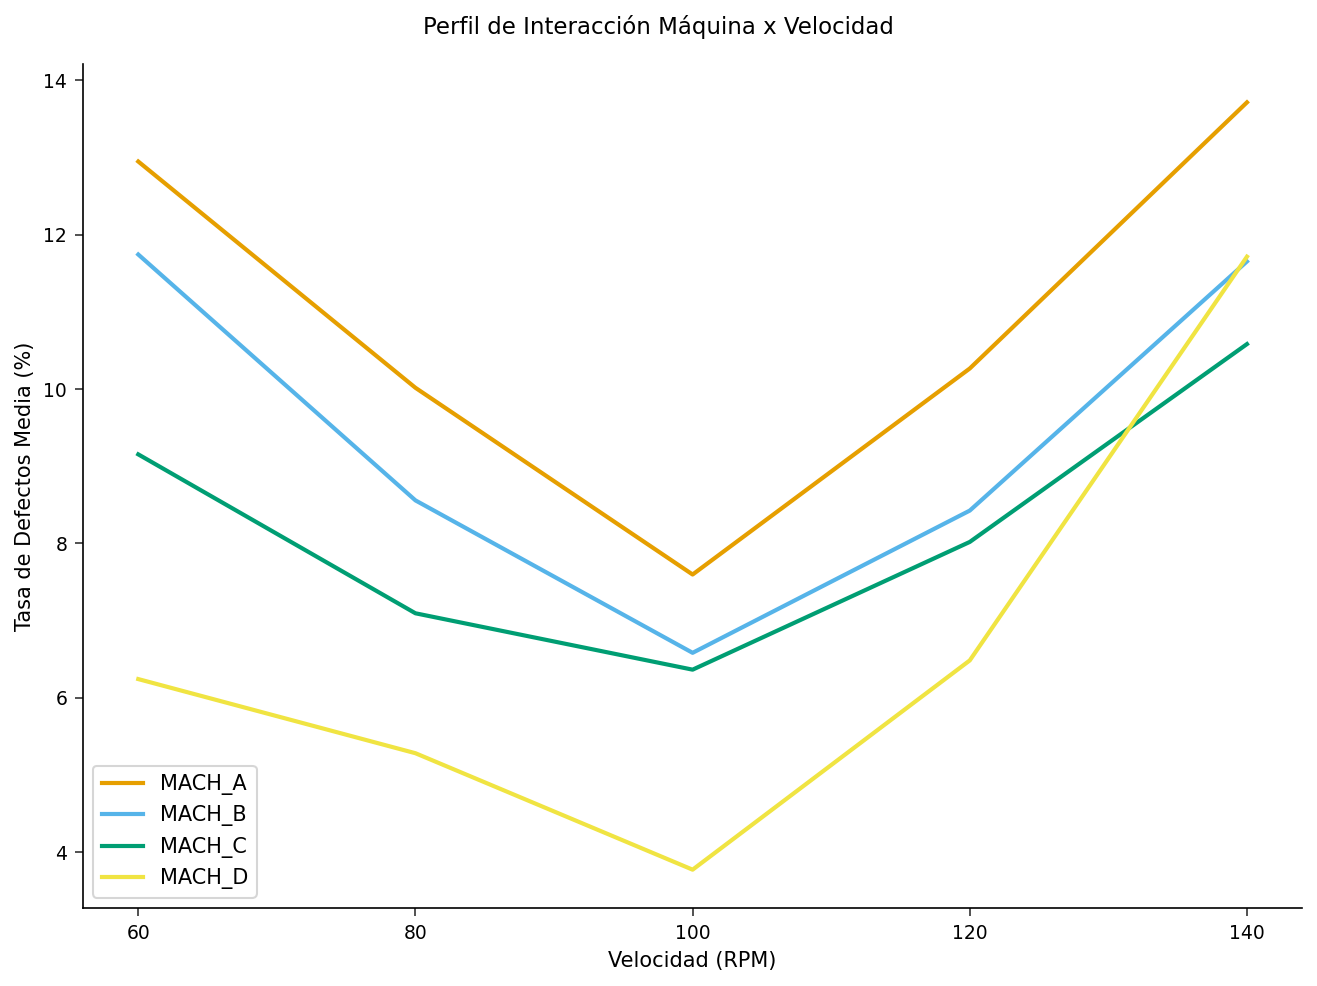

In [3]:
/* --------------------------------------------------------
   Grafico de interaccion: tasa de defectos media por
   velocidad y maquina
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.molding_experiment NOPRINT;
    CLASE machine speed;
    VAR defect_rate;
    SALIDA out=work.cell_means mean=mean_defect;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=work.cell_means(DONDE=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS ETIQUETA='Velocidad (RPM)' VALUES=(60 80 100 120 140);
    YAXIS ETIQUETA='Tasa de Defectos Media (%)';
    TÍTULO 'Perfil de Interacción Máquina x Velocidad';
EJECUTAR;

---

                          Tasa de Defectos y Resistencia a la Tracción por Máquina y Velocidad                          

              The Mixed Procedure              
               Model Information               

Item                                      Value
-------------------------  --------------------
Dependent Variable         Tasa de Defectos (%)
Estimation Method                          REML
Degrees of Freedom Method         Kenward-Roger
Number of Observations                      100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

         Type III Tests of Fixed Effects         

Effect       Num DF    Den DF   F Value    Pr > F
---------  --------  --------  --------  --------
Velocidad         4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    347.3514



NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


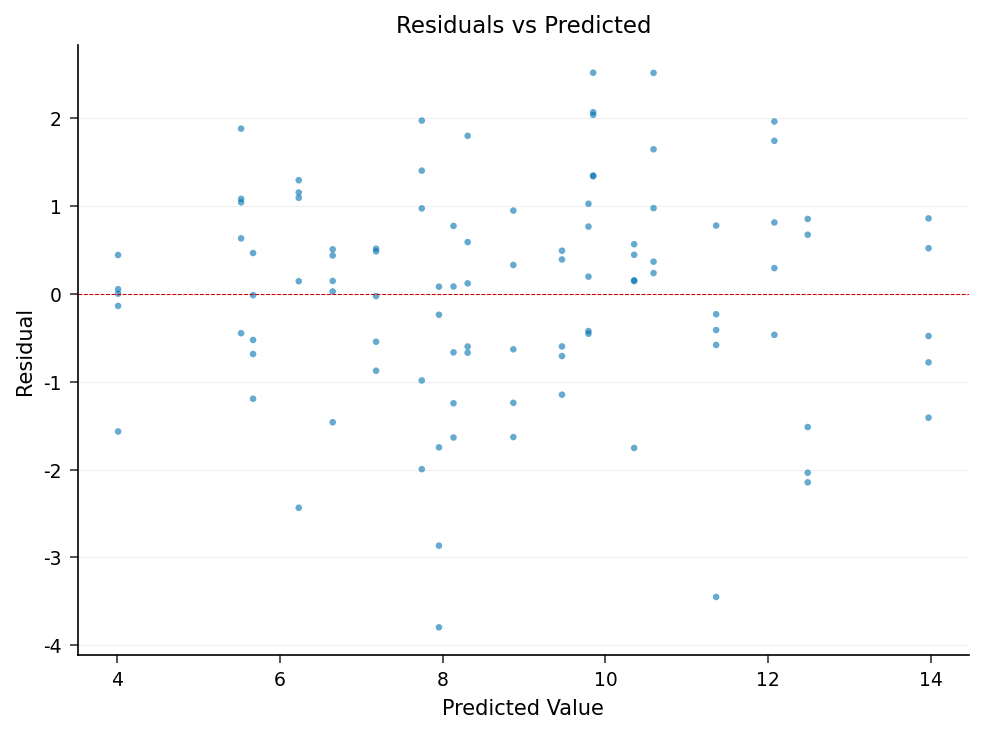

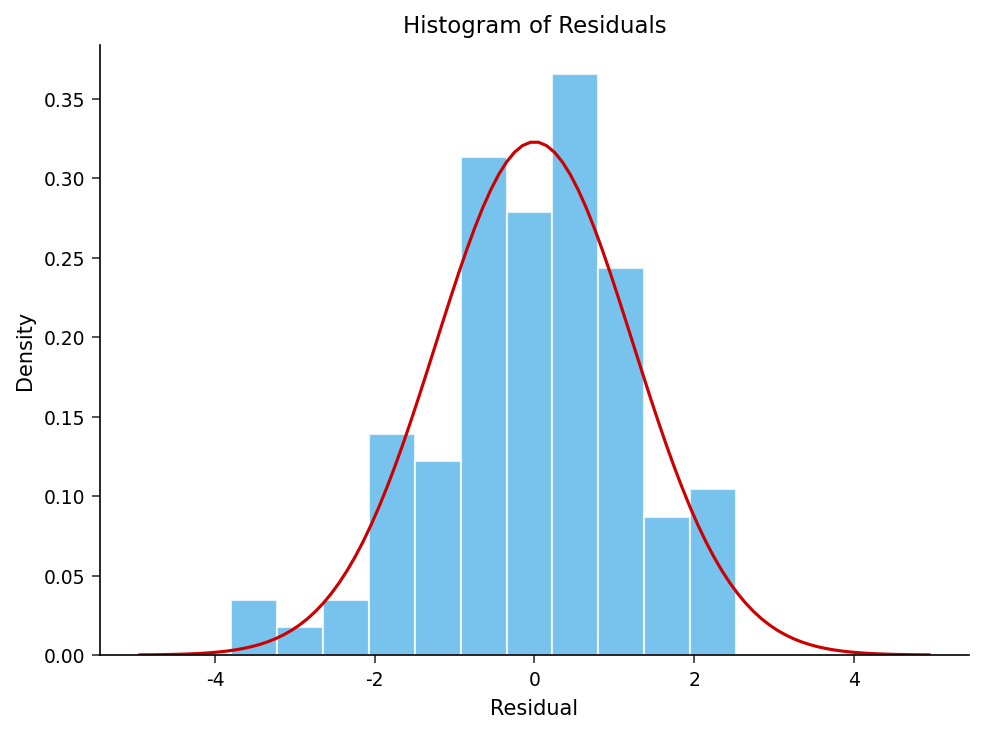

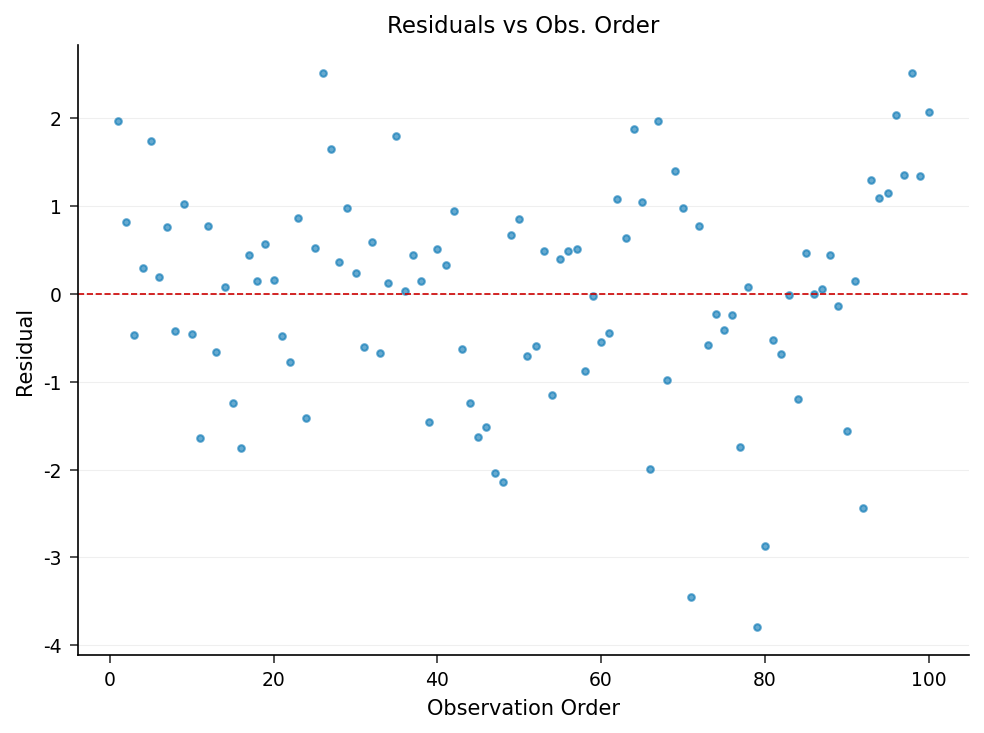

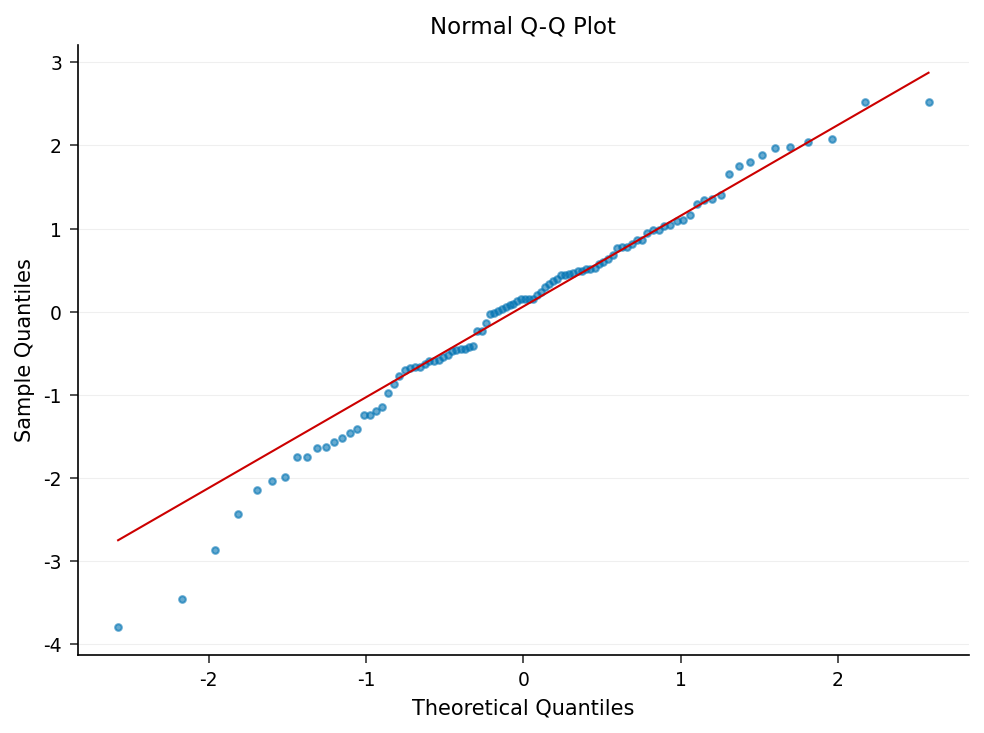

In [4]:
/* --------------------------------------------------------
   Analisis de modelo mixto de parcelas divididas
   La maquina es aleatoria (error de parcela principal)
   La velocidad es fija (factor de subparcela)
   -------------------------------------------------------- */
PROCEDIMIENTO MIXED DATOS=work.molding_experiment METHOD=reml;
    CLASE machine speed_label;
    MODELO defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    ETIQUETA machine='Máquina' speed_label='Velocidad' defect_rate='Tasa de Defectos (%)';
    ODS SALIDA LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    TÍTULO 'Análisis de Parcelas Divididas: Efecto de la Velocidad en la Tasa de Defectos';
EJECUTAR;

In [5]:
/* --------------------------------------------------------
   Identificar la velocidad de operacion optima
   -------------------------------------------------------- */
PROCEDIMIENTO ORDENAR DATOS=work.speed_lsmeans;
    POR estimate;
EJECUTAR;

DATOS work.optimal_speed;
    ESTABLECER work.speed_lsmeans(obs=1);
    MANTENER speed_label estimate stderr lower upper;
    ETIQUETA speed_label = 'Velocidad Óptima'
          estimate = 'Tasa de Defectos Media (LS)'
          lower = 'IC 95% Inferior'
          upper = 'IC 95% Superior';
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.optimal_speed noobs ETIQUETA;
    TÍTULO 'Velocidad de Operación Recomendada para Tasa de Defectos Mínima';
EJECUTAR;

                            Velocidad de Operación Recomendada para Tasa de Defectos Mínima                             

 Velocidad Óptima  Tasa de Defectos Media (LS)  StdErr  IC 95% Inferior  IC 95% Superior
                .                        6.081  0.9266           3.3645           8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Descomposicion de componentes de varianza
   -------------------------------------------------------- */
PROCEDIMIENTO IMPRIMIR DATOS=work.split_covparms noobs;
    ETIQUETA covparm='Componente de Varianza' estimate='Estimación';
    TÍTULO 'Componentes de Varianza: Máquina vs Residual';
EJECUTAR;

                                      Componentes de Varianza: Máquina vs Residual                                      

Componente de Varianza   Estimación
Intercept                    3.1033
Residual                     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### Interpretación

El modelo de parcelas divididas divide la variabilidad de la tasa de defectos en dos estratos. El **componente de varianza de máquina (parcela principal) es 3.10** y la **varianza residual (subparcela) es 1.66**, por lo que las diferencias entre máquinas representan aproximadamente **65%** de la varianza total (3.10 / (3.10 + 1.66)). Esta gran proporción entre máquinas confirma que la máquina es una fuente genuina de variación del proceso y que el diseño de parcelas divididas - en lugar de un análisis totalmente aleatorizado - es el marco correcto.

La prueba Tipo III del efecto fijo de velocidad es altamente significativa: **F(4, 92) = 60.26, p < .0001**, por lo que el ajuste de RPM afecta fuertemente la tasa de defectos. Las medias de mínimos cuadrados trazan una respuesta cuadrática clara con un mínimo en la velocidad intermedia:

| Velocidad | Tasa de defectos media LS (%) | IC 95% |
|-------|------------------------|--------|
| **100 RPM** | **6.08** | 3.36 - 8.80 |
| 80 RPM | 7.74 | 5.02 - 10.46 |
| 120 RPM | 8.30 | 5.58 - 11.02 |
| 60 RPM | 10.02 | 7.31 - 12.74 |
| 140 RPM | 11.92 | 9.20 - 14.63 |

Las comparaciones por pares ajustadas por Tukey muestran que **100 RPM es significativamente menor que cualquier otro ajuste** (p ajustado <= 0.0009 frente a 80, 120, 60 y 140 RPM). Los ajustes de 80 RPM y 120 RPM se ubican en el medio y **no** difieren entre sí (diferencia 0.56, p ajustado = 0.6430), mientras que 60 RPM y 140 RPM producen las tasas de defectos más altas.

**Recomendación de ingeniería:** estandarizar la producción a **100 RPM** en las cuatro máquinas, donde el modelo estima la tasa de defectos más baja (6.08%). Debido a que el componente de varianza de máquina (3.10) es la fuente dominante de variabilidad, el trabajo de seguimiento debería enfocarse en la calibración específica de cada máquina - el perfil de interacción muestra que MACH_D funciona consistentemente más bajo y MACH_A más alto - para cerrar la brecha entre máquinas en el punto de ajuste elegido de 100 RPM.

---

In [7]:
/* --------------------------------------------------------
   Exportar resultados de optimizacion de velocidad para
   ingenieria
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>